# Project: Nkwen Traders Statistical Summary Report

### Step 1 - Load and Inspect the Data Before Calculating Anything

In [39]:
import pandas as pd
data = pd.read_csv("Nkwen_traders_sales.csv")
print("Rows:", len(data))
print("Columns:", data.columns. tolist())
print("\n Missing values in analysis columns")
print("Negative values:")
print("Negative sales:", (data["TotalSale_FCFA"] < 0).sum())
print("Negative prices:", (data["UnitPrice_FCFA"] < 0).sum())
data.isnull().sum()

Rows: 500
Columns: ['TransactionID', 'Date', 'Product', 'Category', 'Quantity', 'UnitPrice_FCFA', 'TotalSale_FCFA', 'PaymentMethod', 'SalesRep', 'CustomerType']

 Missing values in analysis columns
Negative values:
Negative sales: 0
Negative prices: 0


TransactionID      0
Date               0
Product            0
Category           0
Quantity           8
UnitPrice_FCFA     5
TotalSale_FCFA     0
PaymentMethod     10
SalesRep           6
CustomerType       0
dtype: int64

#### Data quality findings: 
##### Several columns contain missing values, including Quantity, Unit price, Payment Method, and Sales Representative. These missing values were documented before the statistical analysis. Because the main statistical analysis focuses on Total Sale and Unit Price, missing values in those columns are excluded from the corresponding calculations. Missing values in other rows unecessarily could reduce the dataset and affect latler business analysis.

### Step 2 - Central Tendency and Spread


In [40]:
# Removing missing values from the Sales column
sales = data["TotalSale_FCFA"].dropna()

sales_mean = sales.mean()
sales_median = sales.median()
sales_mode = sales.mode()
sales_std = sales.std()
print("----- Sales Statistics -----")
print("Mean:", sales_mean, "FCFA")
print("Median:", sales_median, "FCFA")
print("Mode:", sales_mode, "FCFA")
print("Standard deviation:", sales_std, "FCFA")
print()

# Removing missing values from the Price column
price = data["UnitPrice_FCFA"].dropna()

price_mean = price.mean()
price_median = price.median()
price_mode = price.mode()
price_std = price.std()
print("----- Price Statistics -----")
print("Mean:", price_mean, "FCFA")
print("Median:", price_median, "FCFA")
print("Mode:", price_mode, "FCFA")
print("Standard deviation:", price_std, "FCFA")



----- Sales Statistics -----
Mean: 40293.494 FCFA
Median: 10920.0 FCFA
Mode: 0       314.0
1       530.0
2       770.0
3      1770.0
4      1782.0
5      4752.0
6      5610.0
7      7340.0
8      7986.0
9      9000.0
10    12194.0
11    12330.0
12    35760.0
Name: TotalSale_FCFA, dtype: float64 FCFA
Standard deviation: 88619.06839162306 FCFA

----- Price Statistics -----
Mean: 4013.1232323232325 FCFA
Median: 905.0 FCFA
Mode: 0    521.0
Name: UnitPrice_FCFA, dtype: float64 FCFA
Standard deviation: 7824.068807947928 FCFA


#### Sales Interpretation
##### Since the mean (40293.494) is much larger than the median (10920.0), the sales distribution is being pulled upward by unusually large transactions. The standard deviation (88619.07) is large and relative to the median, confirming that sales values vary considerably from one transaction to another. The mode has multiple values meaning that the values have the same number of occurance which is the highest. 

#### Price Interpretation
##### The large difference between the mean and median shows that some products have highers prices than most other produts. The standard deviation shows that the product prices are widely spread out. This makes sense becuase the Nkwen Traders sells inexpensive items such as salt and matches alongside expensive products such as 25kg and 50kg bags of rice.

### Step 3 - Histogram and Shape Interpretation

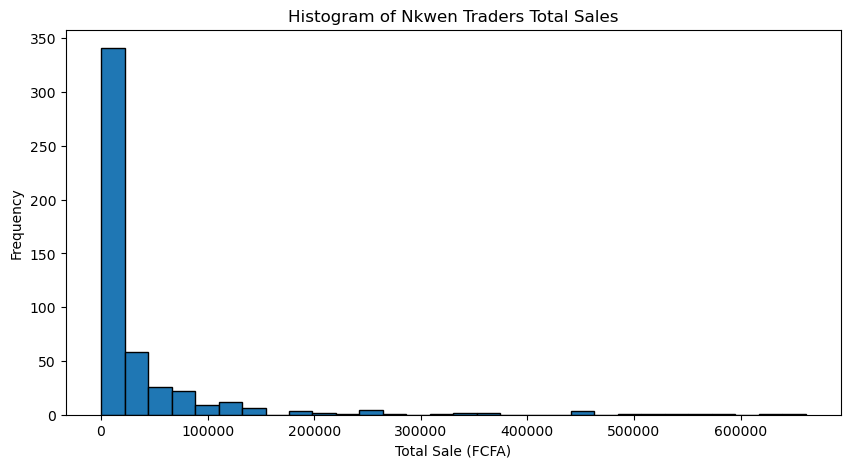

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(data["TotalSale_FCFA"].dropna(), bins=30, edgecolor= "black")
plt.xlabel("Total Sale (FCFA)")
plt.ylabel("Frequency")
plt.title("Histogram of Nkwen Traders Total Sales")
plt.show()

#### Sales histogram interpretation
##### The sales distribution is strongly a right skewed. Most sales are conentrated on lower sales values, while a smaller number of very large transactions create a long tail to the right. 
##### This agrees with the numerical comparism:
##### The mean is much higher than the median. The large transactions are not neccessarily mistakes; they can result from customers buying large quantities, especially higher-priced products.

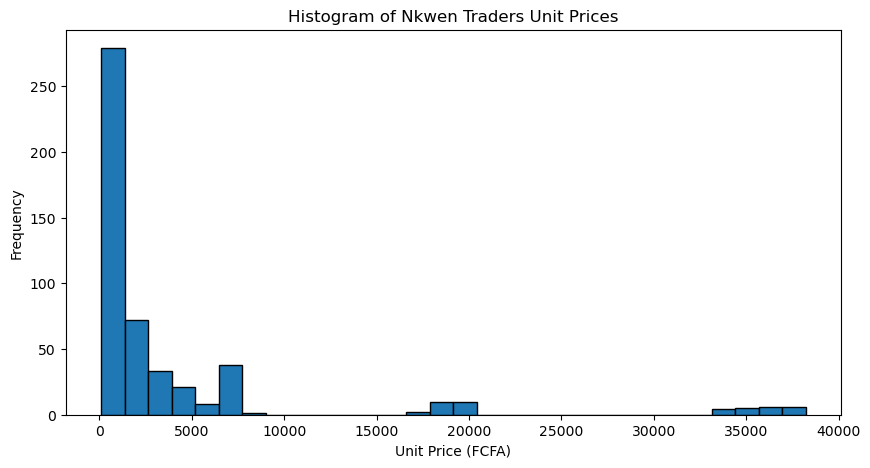

In [41]:
plt.figure(figsize=(10, 5))
plt.hist(data["UnitPrice_FCFA"].dropna(), bins=30, edgecolor= "black")
plt.xlabel("Unit Price (FCFA)")
plt.ylabel("Frequency")
plt.title("Histogram of Nkwen Traders Unit Prices")
plt.show()

#### Unit_Price histogram interpretation
##### The unit-price distribution is also right-skewed but the reason is different from sales. The dataset combines many low-priced products with much more expensive products. In particular, the rice products create a high-price group, so the histogram can show seperate concentrations rather than one smooth bell-shaped distribution. This means the overall price mean is not necessarily the n=best decription of the price of an individual product.

### Step 4 - Z-Scores and Outlier Identification

In [42]:
# Calculating Z-score for Sales
sales = data["TotalSale_FCFA"]

sales_mean = sales.mean()
sales_std = sales.std()

data["Sales_Zscore"] = (sales - sales_mean) / sales_std

#Identify sales outliers
sales_outliers = data[abs(data["Sales_Zscore"]) > 2]

print("Sales Outliers")
print("--------------------")
print(sales_outliers[["TransactionID", "Product", "TotalSale_FCFA", "Sales_Zscore"]])
      

Sales Outliers
--------------------
    TransactionID    Product  TotalSale_FCFA  Sales_Zscore
11       NKW-0012  Rice 50kg        447057.0      4.590022
14       NKW-0015  Rice 50kg        556260.0      5.822297
15       NKW-0016  Rice 50kg        445185.0      4.568898
37       NKW-0038  Rice 50kg        334566.0      3.320645
62       NKW-0063  Rice 50kg        461058.0      4.748013
70       NKW-0071  Rice 50kg        348060.0      3.472915
110      NKW-0111  Rice 25kg        257502.0      2.451036
125      NKW-0126  Rice 50kg        485563.0      5.024534
152      NKW-0153  Rice 50kg        619506.0      6.535981
160      NKW-0161  Rice 50kg        262682.0      2.509488
179      NKW-0180  Rice 25kg        251090.0      2.378681
188      NKW-0189  Rice 50kg        661143.0      7.005823
297      NKW-0298  Rice 25kg        277095.0      2.672128
316      NKW-0317  Rice 50kg        223644.0      2.068974
320      NKW-0321  Rice 25kg        323595.0      3.196846
348      NKW-0349  R

##### The largest sales outlier is Transaction: NKW-0189 with a total sale of 661,143 FCFA.
##### This is an unusually high transaction compared with most other sales.
##### The customer purchased the most number of rice bags (50kg). This could be wholesale purchase or a customer buying in bulk.

In [43]:
# Calculating Z-score for Price
price = data["UnitPrice_FCFA"]

price_mean = price.mean()
price_std = price.std()

data["Price_Zscore"] = (price - price_mean) / price_std

#Identify price outliers
price_outliers = data[abs(data["Price_Zscore"]) > 2]

print("Price Outliers")
print("--------------------")
print(price_outliers[["TransactionID", "Product", "UnitPrice_FCFA", "Price_Zscore"]])
      

Price Outliers
--------------------
    TransactionID    Product  UnitPrice_FCFA  Price_Zscore
0        NKW-0001  Rice 50kg         34928.0      3.951253
7        NKW-0008  Rice 50kg         37414.0      4.268991
11       NKW-0012  Rice 50kg         34389.0      3.882363
14       NKW-0015  Rice 50kg         37084.0      4.226813
15       NKW-0016  Rice 50kg         34245.0      3.863958
53       NKW-0054  Rice 50kg         35760.0      4.057592
62       NKW-0063  Rice 50kg         35466.0      4.020015
70       NKW-0071  Rice 50kg         34806.0      3.935660
97       NKW-0098  Rice 25kg         19791.0      2.016582
134      NKW-0135  Rice 25kg         19925.0      2.033709
139      NKW-0140  Rice 50kg         36962.0      4.211220
152      NKW-0153  Rice 50kg         34417.0      3.885942
160      NKW-0161  Rice 50kg         37526.0      4.283305
166      NKW-0167  Rice 50kg         36400.0      4.139391
188      NKW-0189  Rice 50kg         34797.0      3.934510
233      NKW-0234  R

##### These values are statistically unusual becuase Nkwen Traders sells product with very different price ranges. Items such as matches and salt are inexpensive, while 25kg and 50kg bags of rice are much more expensive.


#CONCLUSION
##### The Z-score analysis identified 22 sales outliers and 27 unit-price outliers using the |z| > 2 rule. The sales outliers are mostly high-priced 25kg and 50kg rice products. These observations should not automatically be treated as errors because they may represent genuine bulk purchases and differences in product prices.

### Step 5 - Bring It Together: The Summary Section

#### Summary
##### - The analysis shows that Nkwen Traders has a highly varied sales pattern. The average transaction value is 40,293.49 FCFA, while the median is 10,920 FCFA. The large difference between the mean and the median indicates that a small number of the high-value transactions significantly increase the average sales value.
##### - Unit prices also vary considerably. The average unit price is 4,013.12 FCFA, compared with a median of 905 FCFA. This  difference is mainly because the business sells products with very different prices ranges, from low-cost items to expensive products such as 25kg and 50kg bags of rice.
##### - Using |Z-score| > 2 as the outlier threshold, the analyis identified 22 unusual unit prices. Most of these unusual observations involve rice and may represent genuine bulk purchases or higher-priced products rather than data errors.
